# 0. Environment Setup

In [24]:
import importlib
import subprocess
import sys

packages = {
    'yfinance': 'yfinance',
    'optuna': 'optuna',
    'xgboost': 'xgboost',
    'tensorflow': 'tensorflow',
    'sklearn': 'scikit-learn'
}

missing = []
for module, pip_name in packages.items():
    if importlib.util.find_spec(module) is None:
        missing.append(pip_name)

if missing:
    print(f'Installing: {", ".join(missing)}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing, '--quiet'])
    print('Done.')
else:
    print('All packages already installed.')

All packages already installed.


In [25]:
import yfinance as yf
import pandas as pd
import numpy as np
import time, os, json

os.makedirs('data', exist_ok=True)
print('Setup complete')

Setup complete


In [26]:
TICKERS = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA',
    'META', 'NVDA', 'JPM',  'V',    'JNJ',
    'WMT',  'PG',   'MA',   'HD',   'BAC',
    'XOM',  'CVX',  'ABBV', 'PFE',  'KO',
    'PEP',  'MRK',  'CSCO', 'INTC', 'NFLX',
    'AMD',  'CRM',  'ORCL', 'ADBE', 'NKE',
    'DIS',  'CMCSA','VZ',   'T',    'MCD',
    'COST', 'IBM',  'GE',   'BA',   'CAT',
    'MMM',  'GS',   'AXP',  'HON',  'UNH',
]

TRAIN_START = '2015-01-01'
TRAIN_END   = '2024-12-31'
TEST_START  = '2025-01-01'
TEST_END    = '2025-12-31'

INTERVAL = '1wk'
N_STEPS  = 20   # 20 weeks (~5 months) of context for LSTM — more meaningful than 5

DATA_DIR = 'data'

print('Config set')

Config set


# Plan
1. Fetch Data from **Multiple Company**
3. Data Preparation — train/test split **before** scaling, RobustScaler (fit on train only), sequence generation per split
4. Build & Train LSTM — two LSTM layers with Dropout, EarlyStopping
5. Predict & Visualize
6. Evaluate — RMSE, MAE, MAPE

---
# 1. Fetching Stock Data

In [27]:
def download_and_pivot(tickers, start, end, interval):
    """Download OHLCV data from yfinance and return a long-format DataFrame."""
    raw = yf.download(tickers, start=start, end=end, interval=interval)

    # Flatten multi-index columns
    raw.columns = [f'{col[0]}_{col[1]}' if col[1] else col[0] for col in raw.columns]

    # Enforce numeric
    num_cols = [c for c in raw.columns if c.startswith(('Open_','High_','Low_','Close_','Volume_'))]
    raw[num_cols] = raw[num_cols].apply(pd.to_numeric, errors='coerce')

    # Wide -> long
    raw = raw.reset_index()
    melted = pd.melt(raw, id_vars=['Date'], value_vars=num_cols,
                     var_name='Type_Ticker', value_name='Value')
    split = melted['Type_Ticker'].str.rsplit('_', n=1, expand=True)
    melted[['Type', 'Ticker']] = split

    pivoted = melted.pivot_table(
        index=['Date', 'Ticker'], columns='Type', values='Value'
    ).reset_index()
    pivoted.columns.name = None

    # Basic cleaning
    pivoted = pivoted.drop_duplicates(subset=['Date', 'Ticker'], keep='last')
    pivoted = pivoted[pivoted['Volume'] >= 0]
    pivoted = pivoted.sort_values(['Ticker', 'Date']).reset_index(drop=True)

    return pivoted


def download_and_cache(tickers, start, end, interval, filename):
    """Load CSV from cache if params match, otherwise download and save."""
    csv_path = os.path.join(DATA_DIR, f'{filename}.csv')
    meta_path = os.path.join(DATA_DIR, f'{filename}_meta.json')

    current_meta = {
        'tickers': sorted(tickers),
        'start': start,
        'end': end,
        'interval': interval,
    }

    # Try loading from cache
    if os.path.exists(csv_path) and os.path.exists(meta_path):
        with open(meta_path, 'r') as f:
            saved_meta = json.load(f)
        if saved_meta == current_meta:
            print(f'Loading cached {filename} from {csv_path}')
            df = pd.read_csv(csv_path, parse_dates=['Date'])
            print(f'{filename}: {df.shape}')
            return df

    # Cache miss or param mismatch — download fresh
    print(f'Downloading {filename}...')
    df = download_and_pivot(tickers, start, end, interval)
    df.to_csv(csv_path, index=False)
    with open(meta_path, 'w') as f:
        json.dump(current_meta, f, indent=2)
    print(f'Saved to {csv_path}  ({df.shape})')
    return df


train_df = download_and_cache(TICKERS, TRAIN_START, TRAIN_END, INTERVAL, 'train_stock_data')
test_df  = download_and_cache(TICKERS, TEST_START,  TEST_END,  INTERVAL, 'test_stock_data')

train_df.head()

Loading cached train_stock_data from data\train_stock_data.csv
train_stock_data: (23490, 8)
Loading cached test_stock_data from data\test_stock_data.csv
test_stock_data: (2340, 8)


,Unnamed: 0,Date,Ticker,Close,High,Low,Open,Volume
0,0,2015-01-01,AAPL,23.864946,24.682224,23.173914,24.671150,8.935724e+08
1,1,2015-01-08,AAPL,24.318993,25.083113,24.031062,24.192747,1.115053e+09
2,2,2015-01-15,AAPL,24.263618,24.598059,23.300160,24.363286,9.480124e+08
3,3,2015-01-22,AAPL,25.539368,26.161740,24.148446,24.420872,1.591688e+09
4,4,2015-01-29,AAPL,26.480682,26.691094,25.594745,25.763073,1.411946e+09


---
# 2. Normality Check
Run three normality tests per feature and visualise with histograms + Q-Q plots.

C:\Users\hp\AppData\Local\Temp\ipykernel_3572\1568472340.py:36: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad = anderson(data, dist='norm')


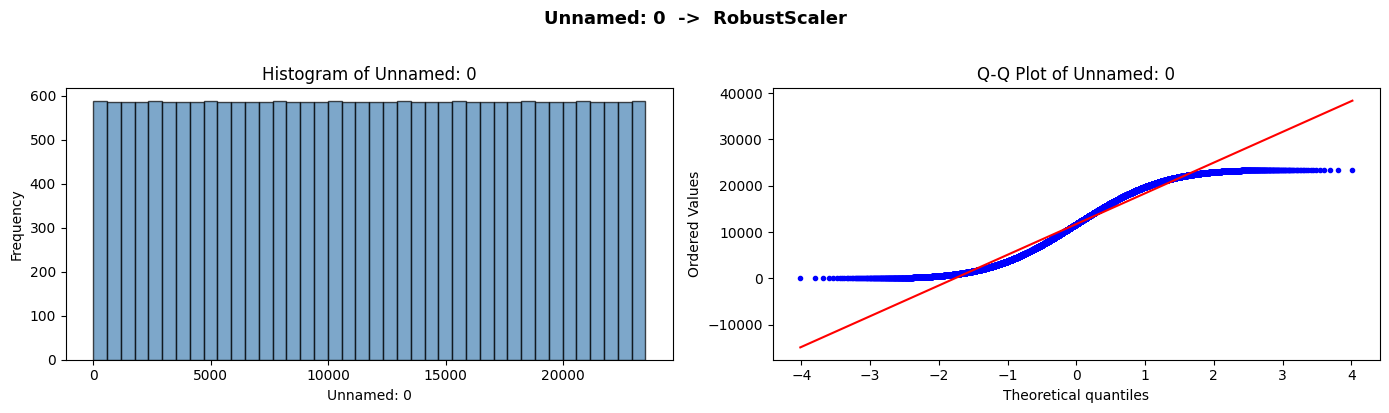

  Shapiro-Wilk     p = 2.2031e-37  NOT normal
  D'Agostino       p = 0.0000e+00  NOT normal
  Anderson-Darling   = 261.1593  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------


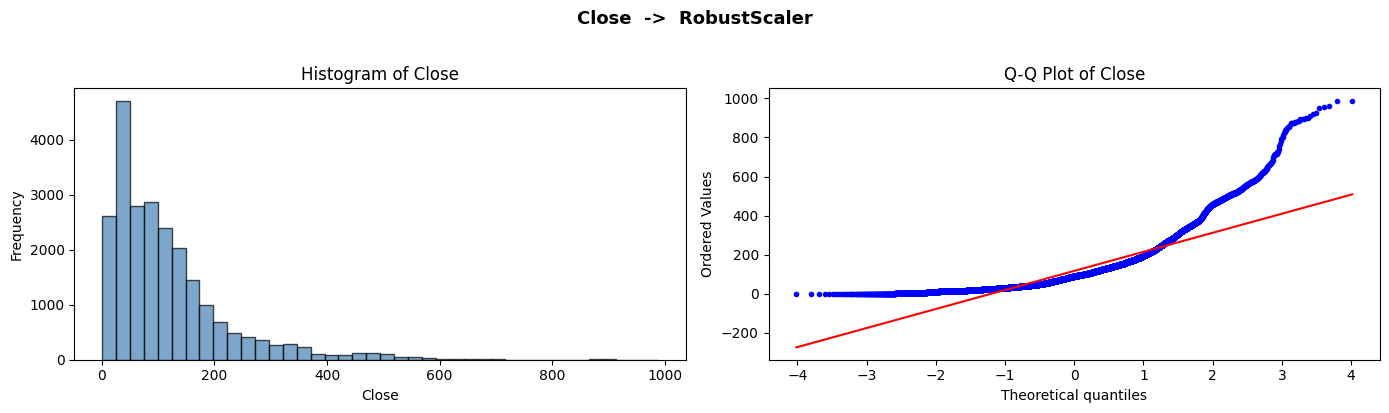

  Shapiro-Wilk     p = 5.6546e-62  NOT normal
  D'Agostino       p = 0.0000e+00  NOT normal
  Anderson-Darling   = 1182.3444  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------


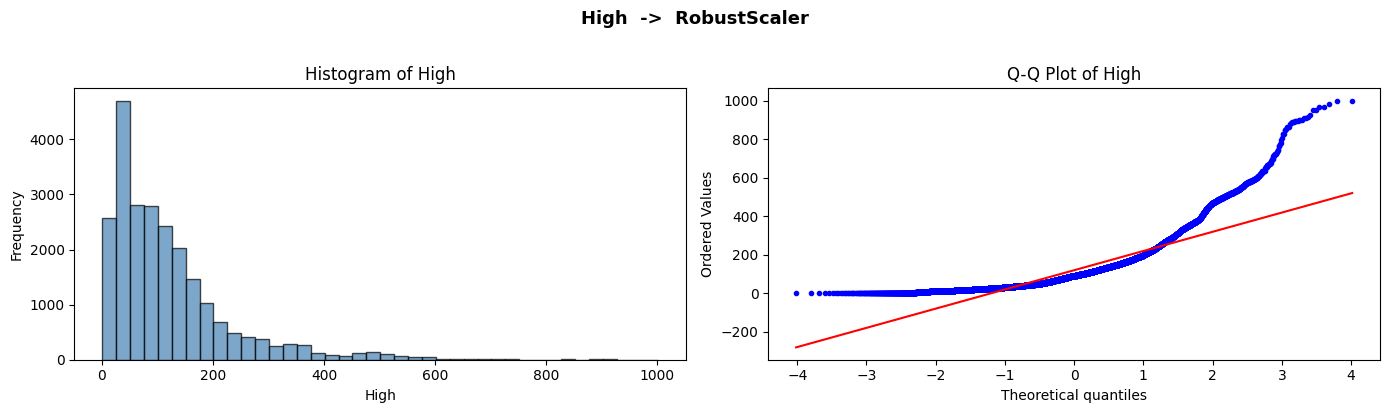

  Shapiro-Wilk     p = 1.6124e-61  NOT normal
  D'Agostino       p = 0.0000e+00  NOT normal
  Anderson-Darling   = 1187.4785  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------


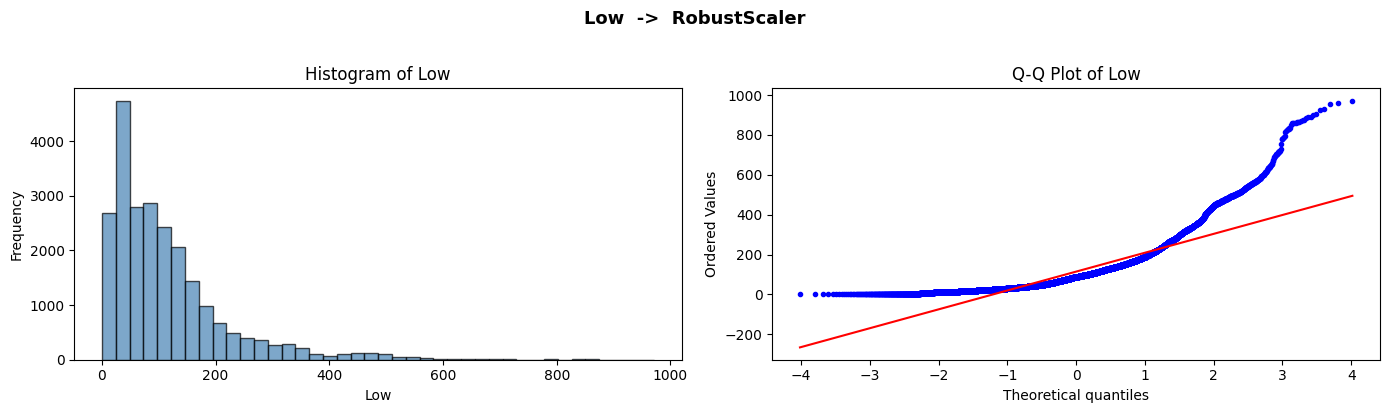

  Shapiro-Wilk     p = 4.8240e-63  NOT normal
  D'Agostino       p = 0.0000e+00  NOT normal
  Anderson-Darling   = 1175.4745  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------


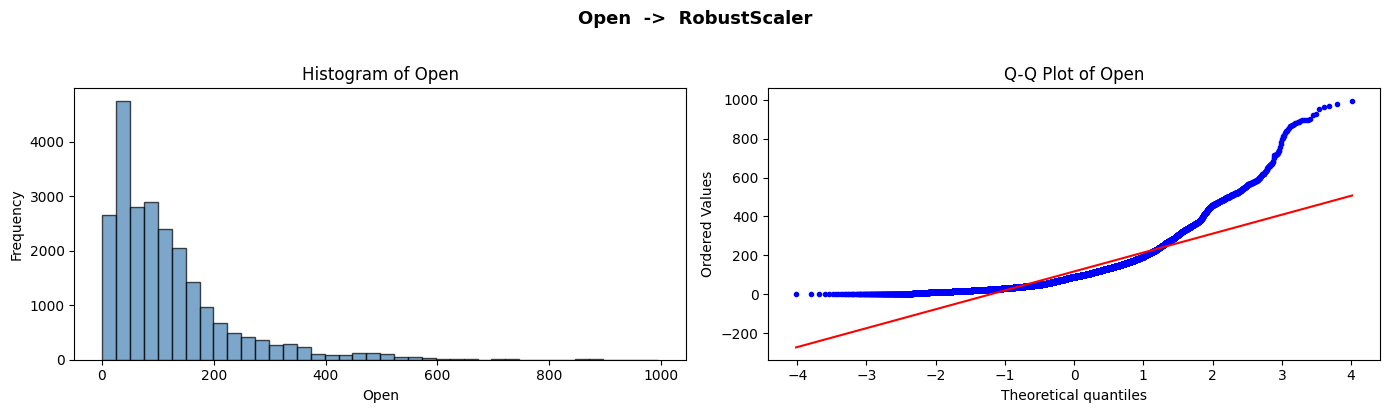

  Shapiro-Wilk     p = 4.9140e-62  NOT normal
  D'Agostino       p = 0.0000e+00  NOT normal
  Anderson-Darling   = 1181.9564  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------


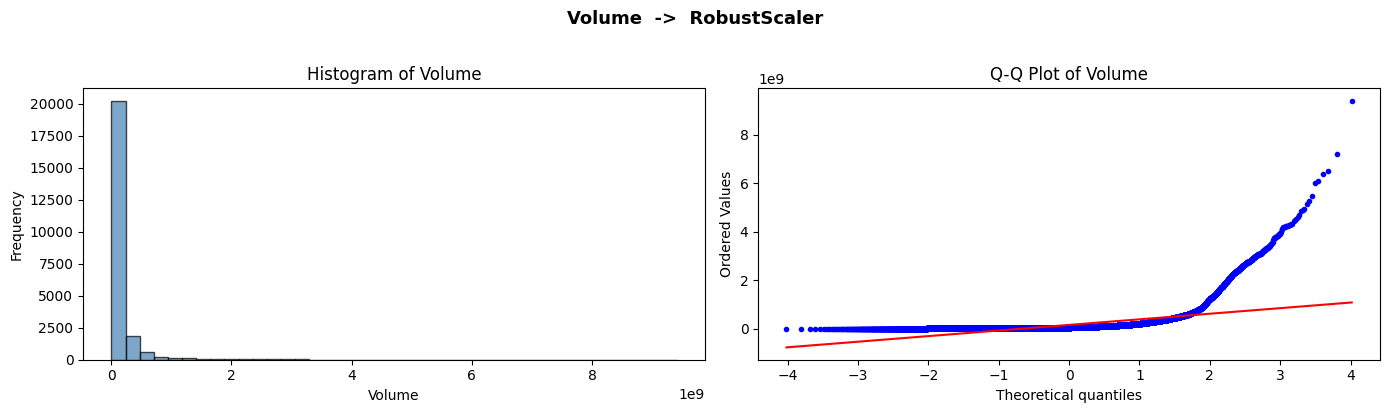

  Shapiro-Wilk     p = 3.9023e-85  NOT normal
  D'Agostino       p = 0.0000e+00  NOT normal
  Anderson-Darling   = 4662.2913  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------

SUMMARY
   Feature  Shapiro p D'Agostino p Anderson stat AD critical 5%  Recommended
Unnamed: 0 2.2031e-37   0.0000e+00      261.1593         0.7520 RobustScaler
     Close 5.6546e-62   0.0000e+00     1182.3444         0.7520 RobustScaler
      High 1.6124e-61   0.0000e+00     1187.4785         0.7520 RobustScaler
       Low 4.8240e-63   0.0000e+00     1175.4745         0.7520 RobustScaler
      Open 4.9140e-62   0.0000e+00     1181.9564         0.7520 RobustScaler
    Volume 3.9023e-85   0.0000e+00     4662.2913         0.7520 RobustScaler


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro, normaltest, anderson
from scipy import stats

SIGNIFICANCE = 0.05
SHAPIRO_MAX = 5000


def recommend_scaler(shapiro_p, dagostino_p, ad_normal):
    normal_votes = sum([shapiro_p > SIGNIFICANCE,
                        dagostino_p > SIGNIFICANCE,
                        ad_normal])
    if normal_votes >= 2:
        return "StandardScaler"
    return "RobustScaler"


summary_rows = []

for col in train_df.columns:
    if col in ('Ticker', 'Date'):
        continue
    data = train_df[col].values.astype(float)

    # Shapiro-Wilk (cap sample)
    shapiro_sample = (np.random.choice(data, SHAPIRO_MAX, replace=False)
                      if len(data) > SHAPIRO_MAX else data)
    _, shapiro_p = shapiro(shapiro_sample)

    # D'Agostino-Pearson
    _, dagostino_p = normaltest(data)

    # Anderson-Darling
    ad = anderson(data, dist='norm')
    ad_normal = ad.statistic < ad.critical_values[2]  # 5 % level

    scaler = recommend_scaler(shapiro_p, dagostino_p, ad_normal)
    summary_rows.append({'Feature': col,
                         'Shapiro p': f'{shapiro_p:.4e}',
                         "D'Agostino p": f'{dagostino_p:.4e}',
                         'Anderson stat': f'{ad.statistic:.4f}',
                         'AD critical 5%': f'{ad.critical_values[2]:.4f}',
                         'Recommended': scaler})

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(data, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_title(f'Histogram of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    stats.probplot(data, dist='norm', plot=axes[1])
    axes[1].set_title(f'Q-Q Plot of {col}')
    axes[1].get_lines()[0].set_markersize(3.0)

    plt.suptitle(f'{col}  ->  {scaler}', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f'  Shapiro-Wilk     p = {shapiro_p:.4e}  {"normal" if shapiro_p > SIGNIFICANCE else "NOT normal"}')
    print(f"  D'Agostino       p = {dagostino_p:.4e}  {'normal' if dagostino_p > SIGNIFICANCE else 'NOT normal'}")
    print(f'  Anderson-Darling   = {ad.statistic:.4f}  (crit 5% = {ad.critical_values[2]:.4f})  {"normal" if ad_normal else "NOT normal"}')
    print(f'  -> Recommended scaler: {scaler}')
    print('-' * 70)

summary_df = pd.DataFrame(summary_rows)
print('\n' + '=' * 80)
print('SUMMARY')
print('=' * 80)
print(summary_df.to_string(index=False))

---
# 3. Data Preparation

## 3.1 Imports & Configuration

In [38]:
from sklearn.preprocessing import RobustScaler

LOOKBACK = 20
TRAIN_RATIO = 0.8

feature_cols = ['Open', 'High', 'Low', 'Volume']
target_col = ['Close']

train_ticker_col = pd.get_dummies(train_df['Ticker'], prefix='ticker')
test_ticker_col = pd.get_dummies(test_df['Ticker'], prefix='ticker')

train_features_raw = pd.concat([train_df[feature_cols], train_ticker_col], axis=1)
test_features_raw = pd.concat([test_df[feature_cols], test_ticker_col], axis=1)

train_target_raw = train_df[target_col]
test_target_raw = test_df[target_col]

## 3.2 Feature Scaling — fit on train only

In [39]:
# Per-company scaling for both features and target
feature_scalers = {}
target_scalers = {}
train_ohlcv_scaled = np.zeros((len(train_df), len(feature_cols)))
test_ohlcv_scaled  = np.zeros((len(test_df),  len(feature_cols)))
train_target_scaled = np.zeros((len(train_df), 1))
test_target_scaled  = np.zeros((len(test_df),  1))

for ticker in train_df['Ticker'].unique():
    f_scaler = RobustScaler()
    t_scaler = RobustScaler()
    train_mask = train_df['Ticker'] == ticker
    test_mask  = test_df['Ticker'] == ticker

    # Fit on this company's train data, transform both train and test
    train_ohlcv_scaled[train_mask] = f_scaler.fit_transform(train_features_raw.loc[train_mask, feature_cols])
    test_ohlcv_scaled[test_mask]   = f_scaler.transform(test_features_raw.loc[test_mask, feature_cols])
    train_target_scaled[train_mask] = t_scaler.fit_transform(train_target_raw[train_mask])
    test_target_scaled[test_mask]   = t_scaler.transform(test_target_raw[test_mask])

    feature_scalers[ticker] = f_scaler
    target_scalers[ticker]  = t_scaler

# Recombine: scaled OHLCV + original ticker dummies
train_features = np.hstack([train_ohlcv_scaled, train_ticker_col.values])
test_features  = np.hstack([test_ohlcv_scaled,  test_ticker_col.values])
train_target = train_target_scaled
test_target  = test_target_scaled

print(f'Train features shape: {train_features.shape}')
print(f'Train target shape  : {train_target.shape}')

Train features shape: (23490, 49)
Train target shape  : (23490, 1)


## 3.4 Sequence Generation
Pad the test input with the last `LOOKBACK` rows from training so the first test sequence uses only train-era data.

In [40]:
def create_sequences_per_company(df, features, target, lookback):
    X, y = [], []
    for _, group_idx in df.groupby('Ticker').groups.items():
        idx = group_idx.values
        for i in range(lookback, len(idx)):
            X.append(features[idx[i - lookback:i]])
            y.append(target[idx[i], 0])
    return np.array(X), np.array(y)


# Training sequences — train_df index aligns with train_features/train_target rows
X_train, y_train = create_sequences_per_company(train_df, train_features, train_target, LOOKBACK)

# Test sequences — concat last LOOKBACK train rows per company before test rows
test_dfs_padded, test_features_list, test_target_list = [], [], []
for ticker, group_idx in train_df.groupby('Ticker').groups.items():
    idx = group_idx.values
    test_mask = test_df['Ticker'] == ticker
    n_test = test_mask.sum()
    if n_test == 0:
        continue
    test_features_list.append(train_features[idx[-LOOKBACK:]])
    test_features_list.append(test_features[test_df.index[test_mask].values])
    test_target_list.append(train_target[idx[-LOOKBACK:]])
    test_target_list.append(test_target[test_df.index[test_mask].values])
    test_dfs_padded.append(pd.concat([
        train_df.iloc[idx[-LOOKBACK:]],
        test_df.loc[test_mask]
    ], ignore_index=True))

test_df_padded = pd.concat(test_dfs_padded, ignore_index=True)
test_features_padded = np.vstack(test_features_list)
test_target_padded = np.vstack(test_target_list)

X_test, y_test = create_sequences_per_company(
    test_df_padded, test_features_padded, test_target_padded, LOOKBACK
)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  y_test : {y_test.shape}')

X_train: (22590, 20, 49)  y_train: (22590,)
X_test : (2340, 20, 49)  y_test : (2340,)


---
# 4. Building and Training LSTM

In [41]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input, Bidirectional
from keras.callbacks import EarlyStopping

model = Sequential([
    Input(shape=(LOOKBACK, X_train.shape[2])),
    Bidirectional(LSTM(100, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(100, return_sequences=False)),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 20, 200)        │       120,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 200)            │       240,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,001 (1.38 MB)

 Trainable params: 361,001 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 44s 55ms/step - loss: 0.0331 - mae: 0.1126 - val_loss: 0.0128 - val_mae: 0.0844
Epoch 2/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - loss: 0.0179 - mae: 0.0883 - val_loss: 0.0085 - val_mae: 0.0673
Epoch 3/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 27s 42ms/step - loss: 0.0172 - mae: 0.0840 - val_loss: 0.0092 - val_mae: 0.0675
Epoch 4/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 29s 45ms/step - loss: 0.0152 - mae: 0.0795 - val_loss: 0.0075 - val_mae: 0.0643
Epoch 5/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - loss: 0.0140 - mae: 0.0771 - val_loss: 0.0075 - val_mae: 0.0623
Epoch 6/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - loss: 0.0140 - mae: 0.0765 - val_loss: 0.0072 - val_mae: 0.0618
Epoch 7/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 29s 45ms/step - loss: 0.0137 - mae: 0.0752 - val_loss: 0.0075 - val_mae: 0.0666
Epoch 8/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 39s 42ms/step - loss: 0.0134 - mae: 0.0744 - val_loss: 0.0097 - val_mae: 0.0730
Epoch 9/100
636/636 ━━━━━━━━━━━━

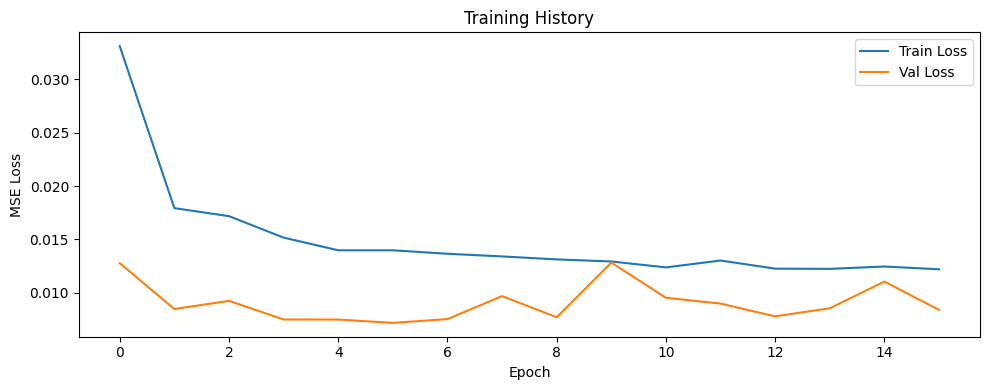

In [43]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

---
# 5. Making Predictions

In [44]:
pred_scaled = model.predict(X_test)

# Track which test samples belong to which company
test_company_labels = []
for ticker, group_idx in test_df_padded.groupby('Ticker').groups.items():
    idx = group_idx.values
    for i in range(LOOKBACK, len(idx)):
        test_company_labels.append(ticker)
test_company_labels = np.array(test_company_labels)

# Inverse-transform per company using stored target_scalers
prediction = np.zeros_like(pred_scaled)
y_test_actual = np.zeros((len(y_test), 1))
for ticker in np.unique(test_company_labels):
    mask = test_company_labels == ticker
    prediction[mask] = target_scalers[ticker].inverse_transform(pred_scaled[mask])
    y_test_actual[mask] = target_scalers[ticker].inverse_transform(y_test[mask].reshape(-1, 1))

print(f'Predictions shape: {prediction.shape}')
print(f'Actuals shape     : {y_test_actual.shape}')

74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
Predictions shape: (2340, 1)
Actuals shape     : (2340, 1)


---
# 6. Visualisation

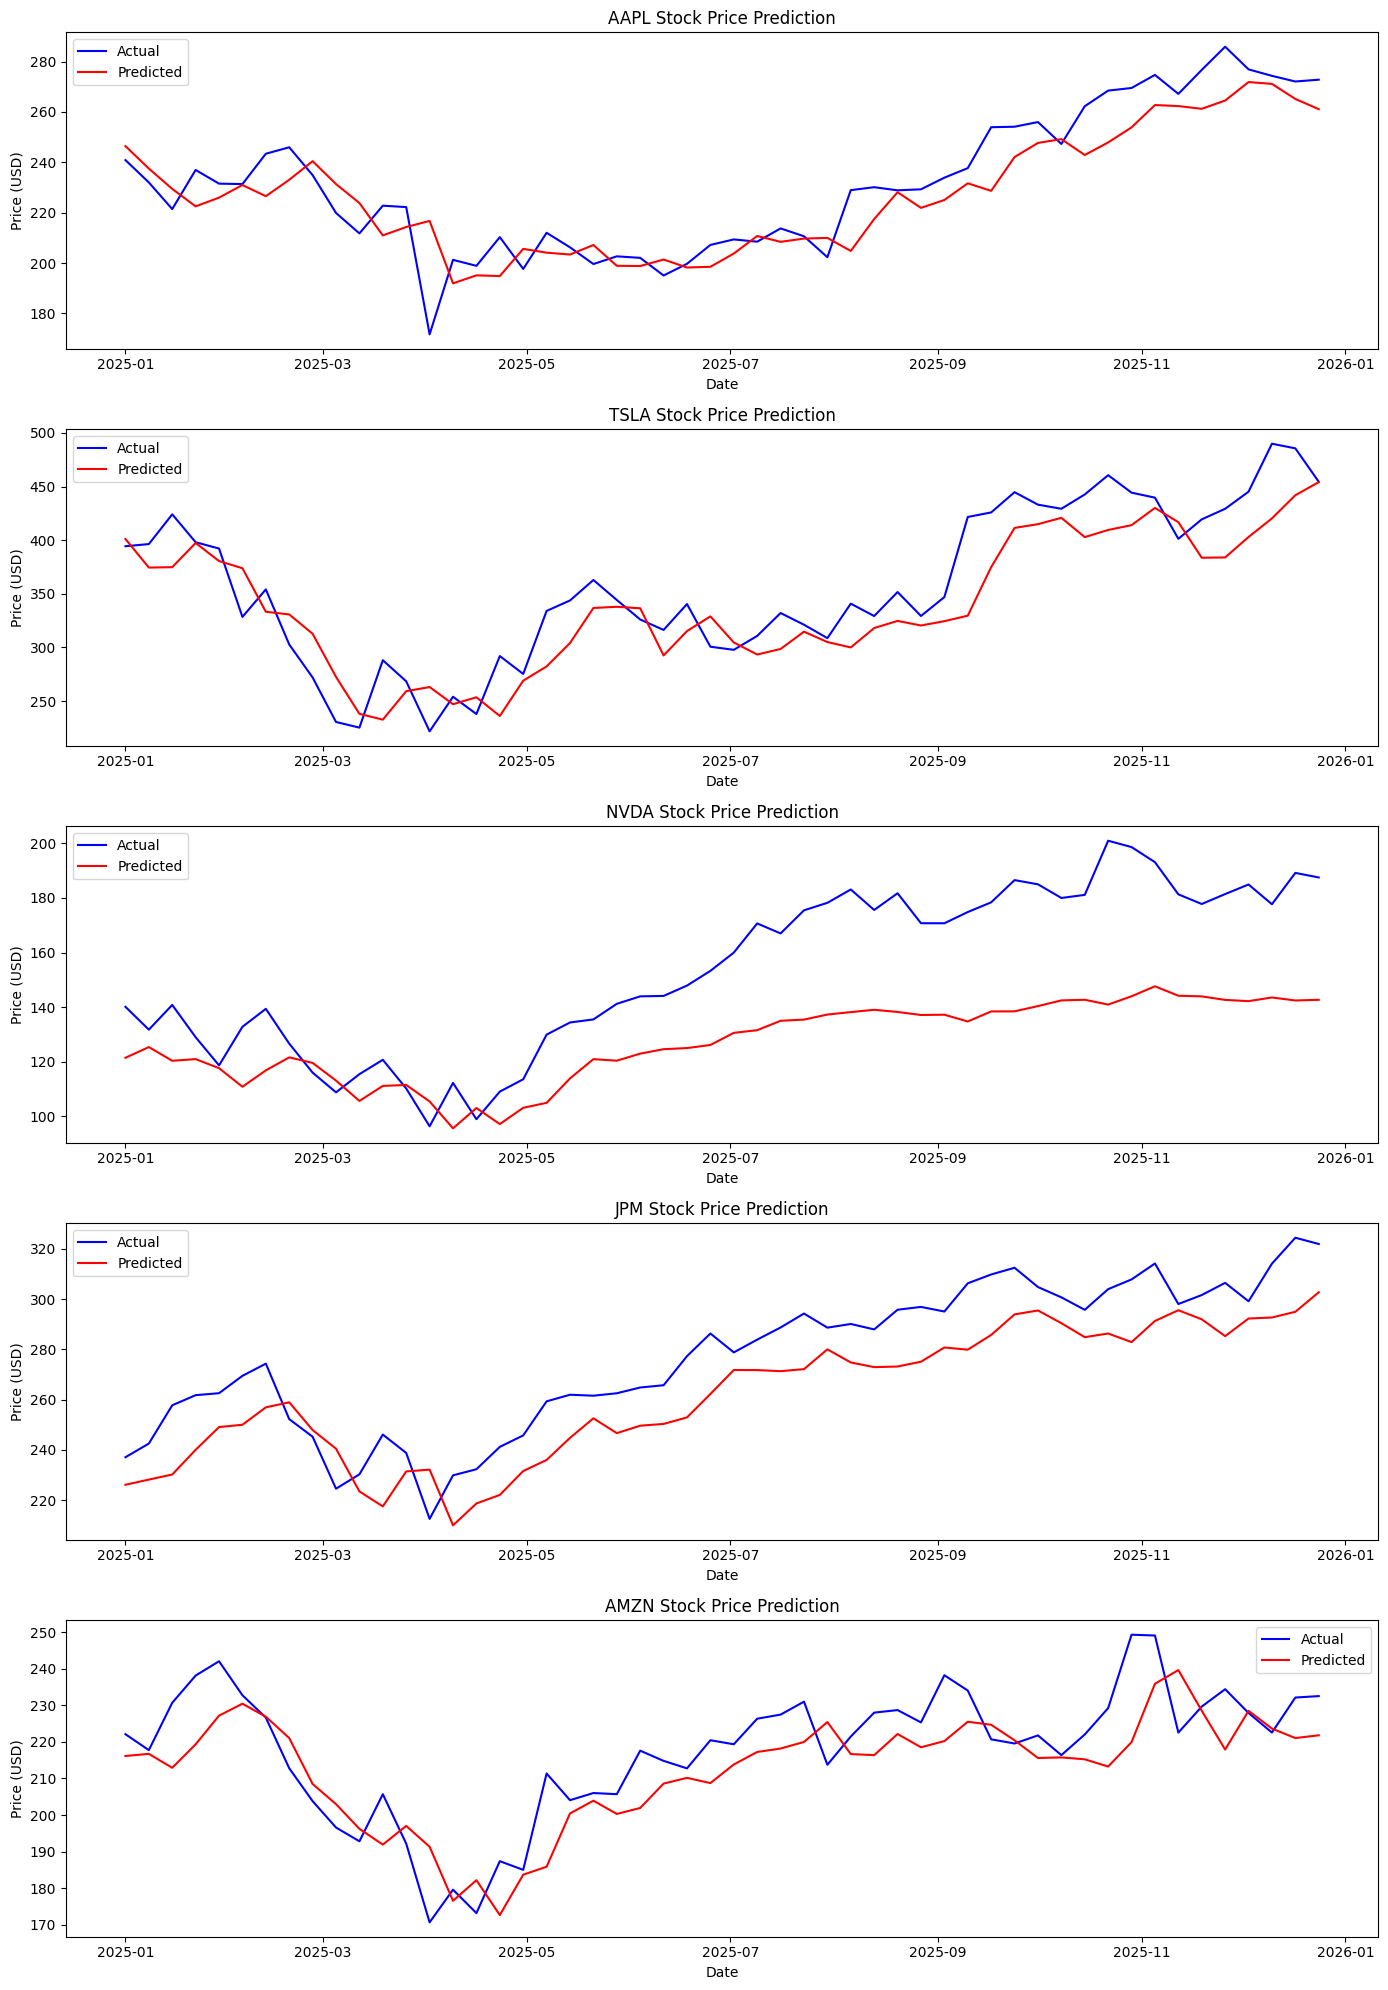

In [45]:
selected_tickers = ['AAPL', 'TSLA', 'NVDA', 'JPM', 'AMZN']
fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 4 * len(selected_tickers)))

for ax, ticker in zip(axes, selected_tickers):
    mask = test_company_labels == ticker
    dates = test_df[test_df['Ticker'] == ticker]['Date'].values
    ax.plot(dates, y_test_actual[mask], label='Actual', color='blue')
    ax.plot(dates, prediction[mask], label='Predicted', color='red')
    ax.set_title(f'{ticker} Stock Price Prediction')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.legend()

plt.tight_layout()
plt.show()

---
# 7. Model Evaluation

In [49]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score

# Overall metrics
mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

print('=' * 45)
print('LSTM Multi-Company — Overall Test Metrics')
print('=' * 45)

print(f'  MSE  : {mse:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  MAPE : {mape:.2f}%')
print('=' * 45)

# Per-company breakdown
print('\nPer-Company Metrics:')
print(f'{"Ticker":<8} {"RMSE":>8} {"MAE":>8} {"MAPE":>8}')
print('-' * 36)
for ticker in sorted(np.unique(test_company_labels)):
    mask = test_company_labels == ticker
    t_mse  = mean_squared_error(y_test_actual[mask], prediction[mask])
    t_rmse = np.sqrt(t_mse)
    t_mae  = mean_absolute_error(y_test_actual[mask], prediction[mask])
    t_mape = np.mean(np.abs((y_test_actual[mask] - prediction[mask]) / y_test_actual[mask])) * 100
    print(f'{ticker:<8} {t_rmse:>8.4f} {t_mae:>8.4f} {t_mape:>7.2f}%')

LSTM Multi-Company — Overall Test Metrics
  MSE  : 398.1394
  RMSE : 19.9534
  MAE  : 11.8160
  MAPE : 4.78%

Per-Company Metrics:
Ticker       RMSE      MAE     MAPE
------------------------------------
AAPL      12.4433   9.7448    4.25%
ABBV       9.3835   7.5838    3.78%
ADBE      18.7663  14.6082    3.93%
AMD       15.0077  11.0435    7.22%
AMZN      11.1385   8.8873    4.06%
AXP       18.7261  15.6522    4.99%
BA        11.4878   9.0798    4.82%
BAC        2.2122   1.8624    4.10%
CAT       35.7124  29.7599    6.80%
CMCSA      1.2063   0.8794    2.97%
COST      36.9551  29.0017    3.00%
CRM       13.6482  10.4461    3.93%
CSCO       2.5181   1.9670    3.03%
CVX        5.7787   3.9408    2.76%
DIS        5.2201   3.4797    3.39%
GE        18.4397  16.3088    6.50%
GOOGL     15.0134  11.3712    5.03%
GS        51.5165  46.3190    6.78%
HD        12.5101   9.6609    2.63%
HON        7.4334   5.2896    2.71%
IBM       38.4611  35.0819   12.95%
INTC       3.2655   2.3631    8.56%
JNJ 

## 8. Visualization

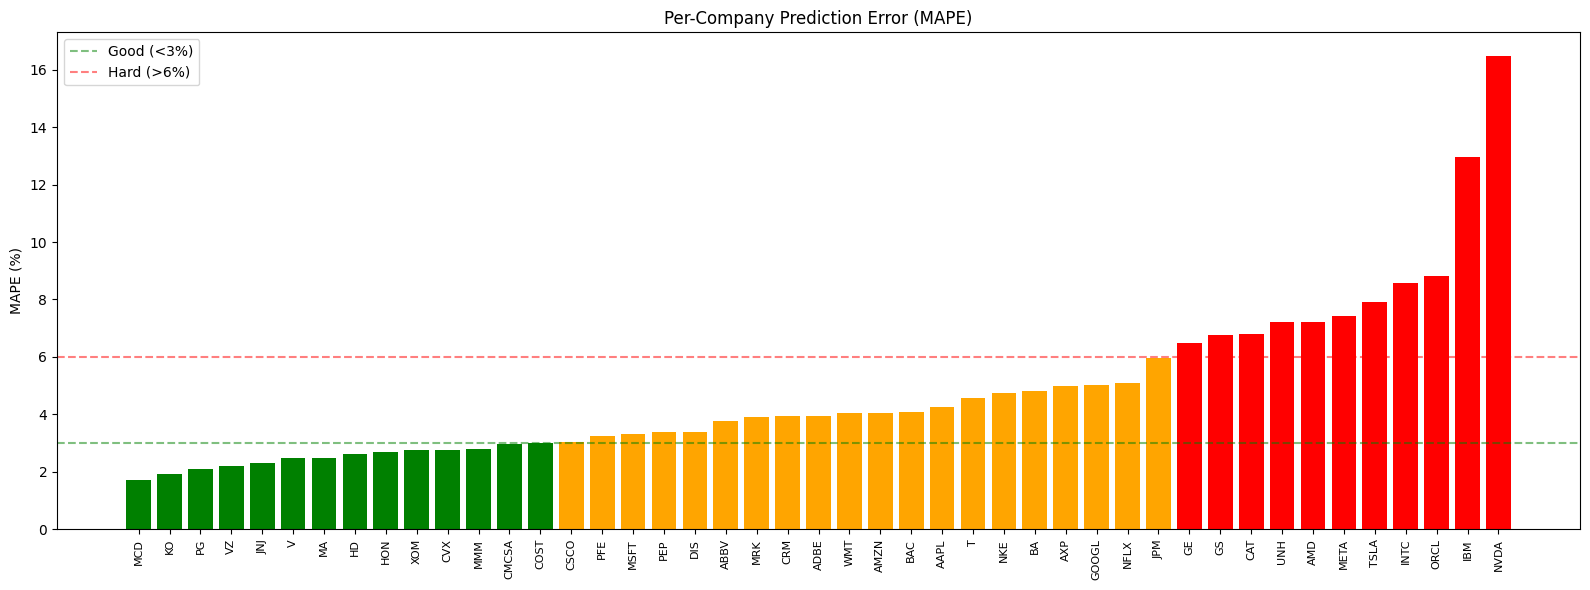

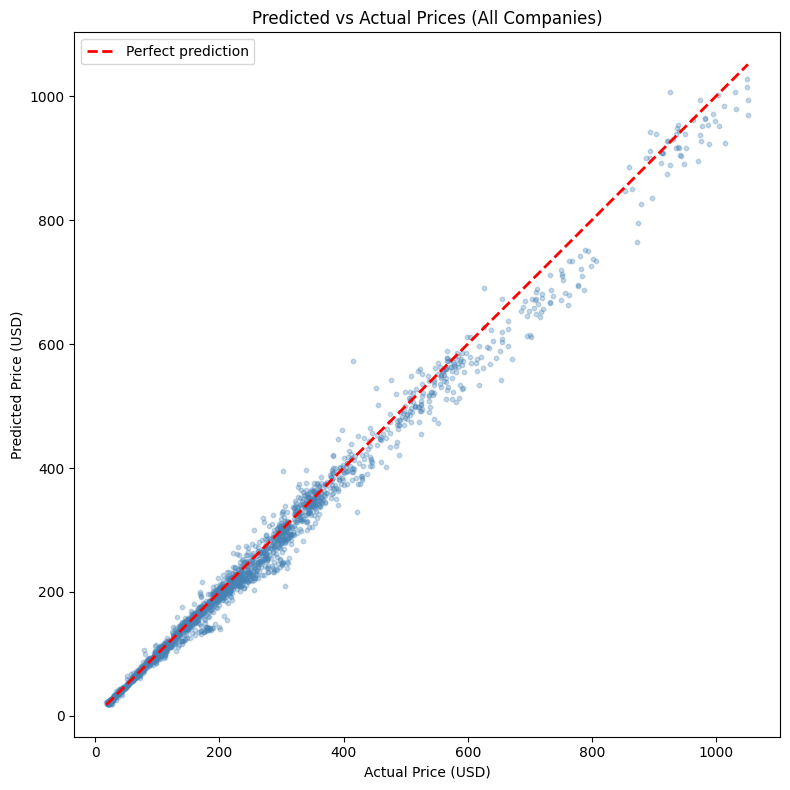

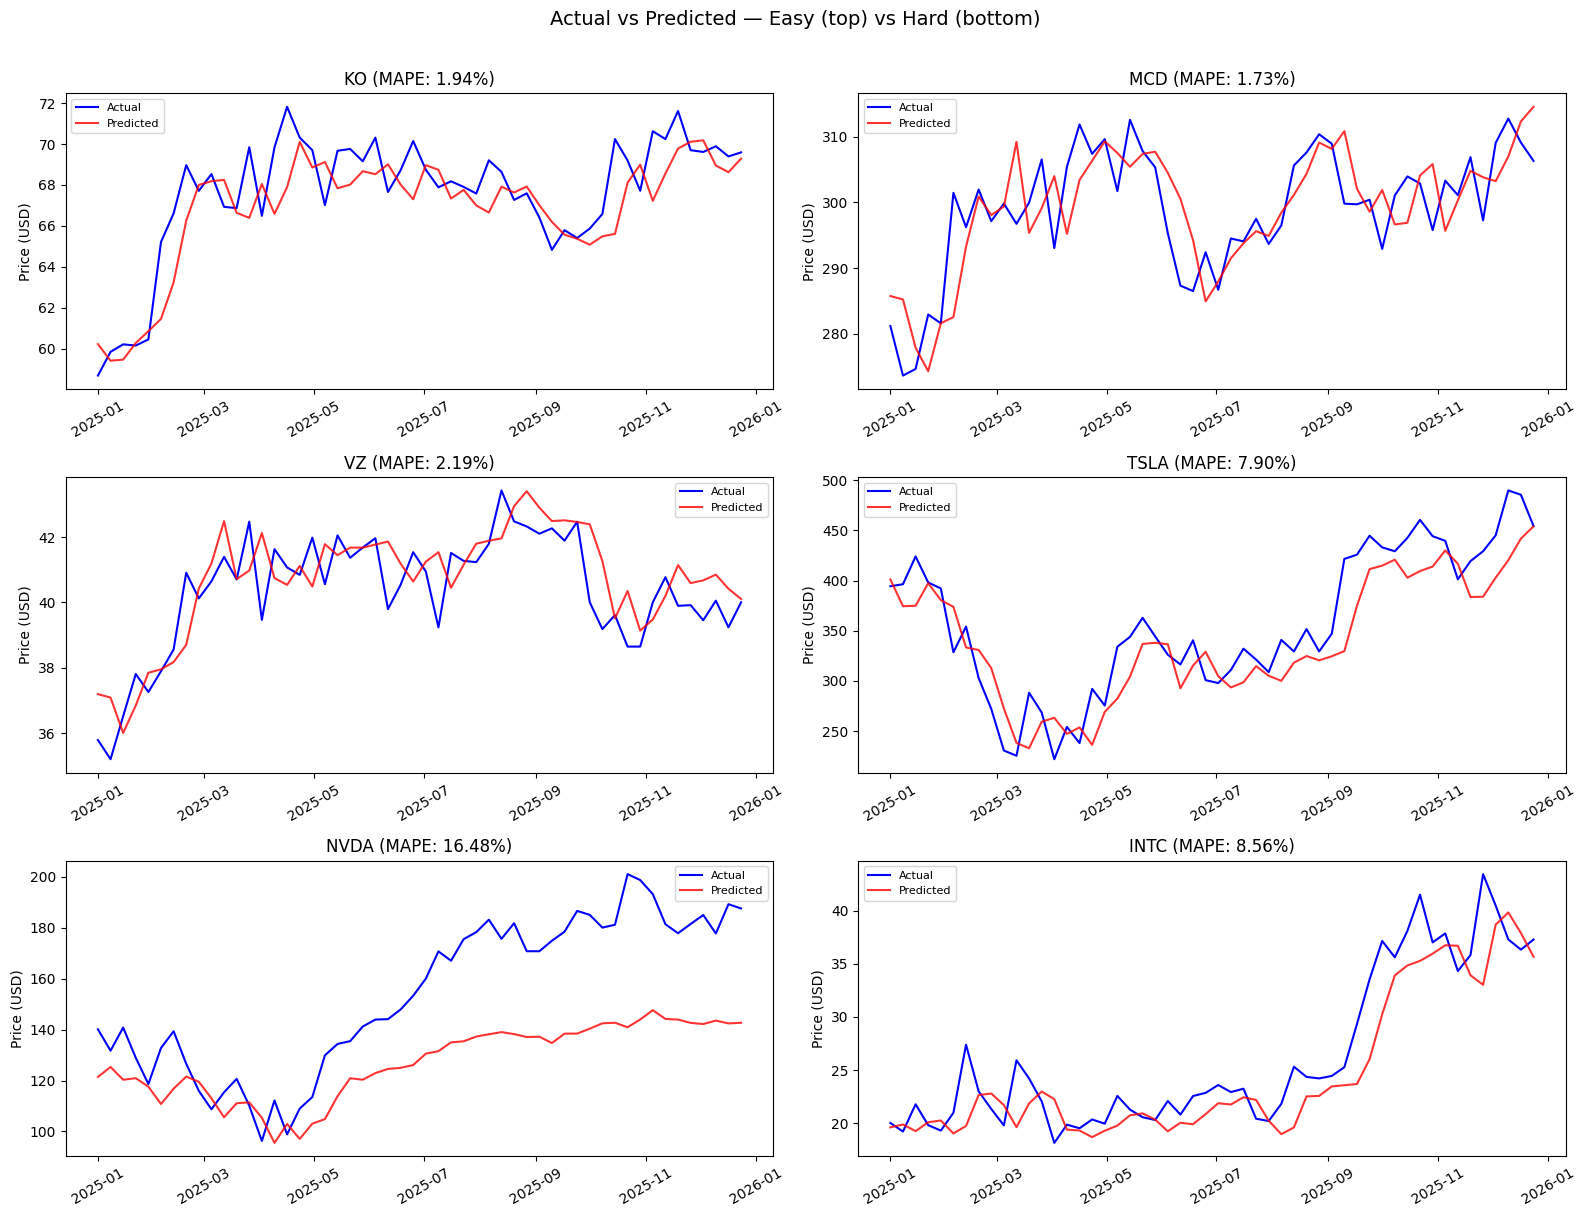

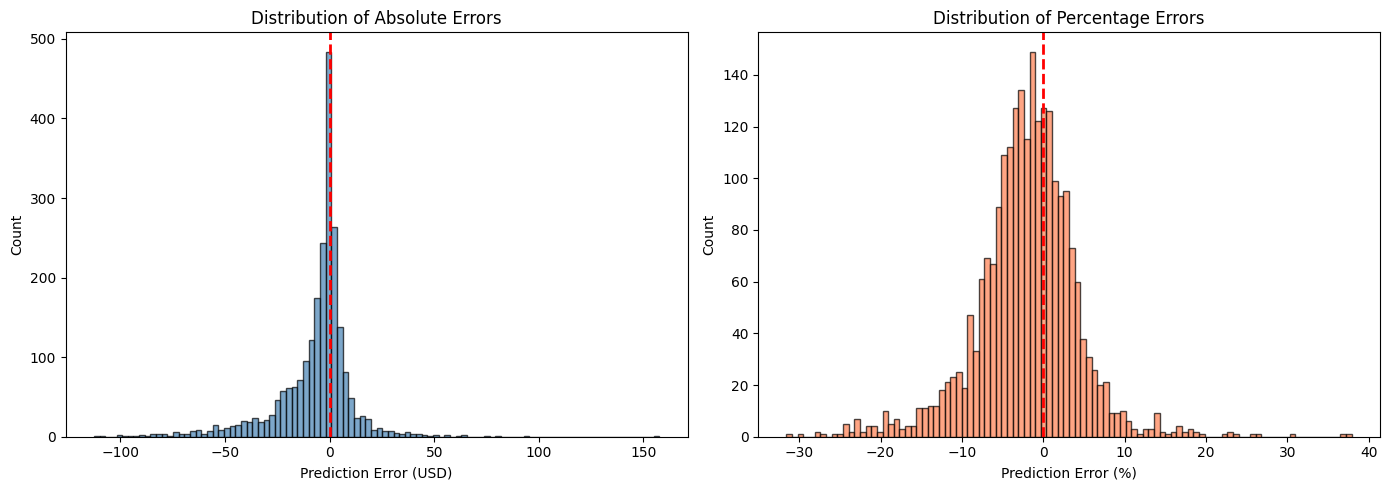

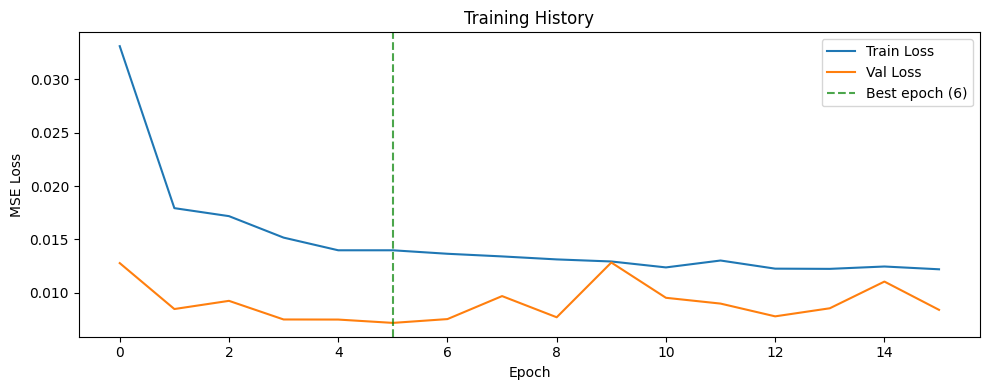

In [50]:
# --- 8a. Per-Company MAPE Bar Chart ---
from sklearn.metrics import mean_squared_error, mean_absolute_error

company_metrics = {}
for ticker in sorted(np.unique(test_company_labels)):
    mask = test_company_labels == ticker
    t_mape = np.mean(np.abs((y_test_actual[mask] - prediction[mask]) / y_test_actual[mask])) * 100
    t_mae  = mean_absolute_error(y_test_actual[mask], prediction[mask])
    company_metrics[ticker] = {'MAPE': t_mape, 'MAE': t_mae}

tickers_sorted = sorted(company_metrics, key=lambda t: company_metrics[t]['MAPE'])
mapes = [company_metrics[t]['MAPE'] for t in tickers_sorted]
colors = ['green' if m < 3 else 'orange' if m < 6 else 'red' for m in mapes]

plt.figure(figsize=(16, 6))
plt.bar(range(len(tickers_sorted)), mapes, color=colors)
plt.xticks(range(len(tickers_sorted)), tickers_sorted, rotation=90, fontsize=8)
plt.axhline(y=3, color='green', linestyle='--', alpha=0.5, label='Good (<3%)')
plt.axhline(y=6, color='red', linestyle='--', alpha=0.5, label='Hard (>6%)')
plt.ylabel('MAPE (%)')
plt.title('Per-Company Prediction Error (MAPE)')
plt.legend()
plt.tight_layout()
plt.show()

# --- 8b. Predicted vs Actual Scatter Plot ---
plt.figure(figsize=(8, 8))
plt.scatter(y_test_actual, prediction, alpha=0.3, s=10, color='steelblue')
min_val = min(y_test_actual.min(), prediction.min())
max_val = max(y_test_actual.max(), prediction.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Predicted vs Actual Prices (All Companies)')
plt.legend()
plt.tight_layout()
plt.show()

# --- 8c. Price Line Plots (6 selected stocks: 3 easy, 3 hard) ---
selected = ['KO', 'MCD', 'VZ', 'TSLA', 'NVDA', 'INTC']
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for ax, ticker in zip(axes.flatten(), selected):
    mask = test_company_labels == ticker
    dates = test_df[test_df['Ticker'] == ticker]['Date'].values
    ax.plot(dates, y_test_actual[mask], label='Actual', color='blue', linewidth=1.5)
    ax.plot(dates, prediction[mask], label='Predicted', color='red', linewidth=1.5, alpha=0.8)
    t_mape = company_metrics[ticker]['MAPE']
    ax.set_title(f'{ticker} (MAPE: {t_mape:.2f}%)')
    ax.set_ylabel('Price (USD)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Actual vs Predicted — Easy (top) vs Hard (bottom)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- 8d. Prediction Error Distribution ---
errors = (prediction - y_test_actual).flatten()
pct_errors = (errors / y_test_actual.flatten()) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(errors, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Prediction Error (USD)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Absolute Errors')

axes[1].hist(pct_errors, bins=100, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error (%)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Percentage Errors')

plt.tight_layout()
plt.show()

# --- 8e. Training History ---
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
best_epoch = np.argmin(history.history['val_loss']) + 1
plt.axvline(x=best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.tight_layout()
plt.show()